# Teste de Algoritmos Alternativos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

## Carregamento dos Dados e Preparação

In [3]:
df = pd.read_csv('data/raw/hepg2.csv')

X = df[['% DMSO', 'TREHALOSE']]
y = df['VIABILIDADE']

# Divisão em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalização para a Rede Neural e para o SVR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.fit_transform(X)

# Validador cruzado padrão para todos
cv = KFold(n_splits=5, shuffle=True, random_state=42)

## Treinamento e Avaliação: Rede Neural (MLP)

In [4]:
print("Treinando Rede Neural Artificial...")
mlp_model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=42, early_stopping=True)
mlp_model.fit(X_train_scaled, y_train)

y_pred_mlp = mlp_model.predict(X_test_scaled)
r2_mlp = r2_score(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))

print(f"MLP -> R²: {r2_mlp:.4f} | RMSE: {rmse_mlp:.4f}%")

Treinando Rede Neural Artificial...
MLP -> R²: 0.6122 | RMSE: 21.9697%


## Treinamento e Avaliação: Máquina de Vetores de Suporte (SVR)

In [5]:
print("Treinando SVR (Support Vector Regression)...")
svr_model = SVR(kernel='rbf', C=100, gamma=0.1)
svr_model.fit(X_train_scaled, y_train)

y_pred_svr = svr_model.predict(X_test_scaled)
r2_svr = r2_score(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

print(f"SVR -> R²: {r2_svr:.4f} | RMSE: {rmse_svr:.4f}%")

Treinando SVR (Support Vector Regression)...
SVR -> R²: 0.5441 | RMSE: 23.8188%


## Treinamento e Avaliação: XGBoost

In [6]:
print("Treinando XGBoost Regressor...")
# O XGBoost não usa os dados escalonados (X_train_scaled), ele lida bem com a escala bruta (X_train)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"XGBoost -> R²: {r2_xgb:.4f} | RMSE: {rmse_xgb:.4f}%")

Treinando XGBoost Regressor...
XGBoost -> R²: 0.9773 | RMSE: 5.3198%


## Visualização Científica

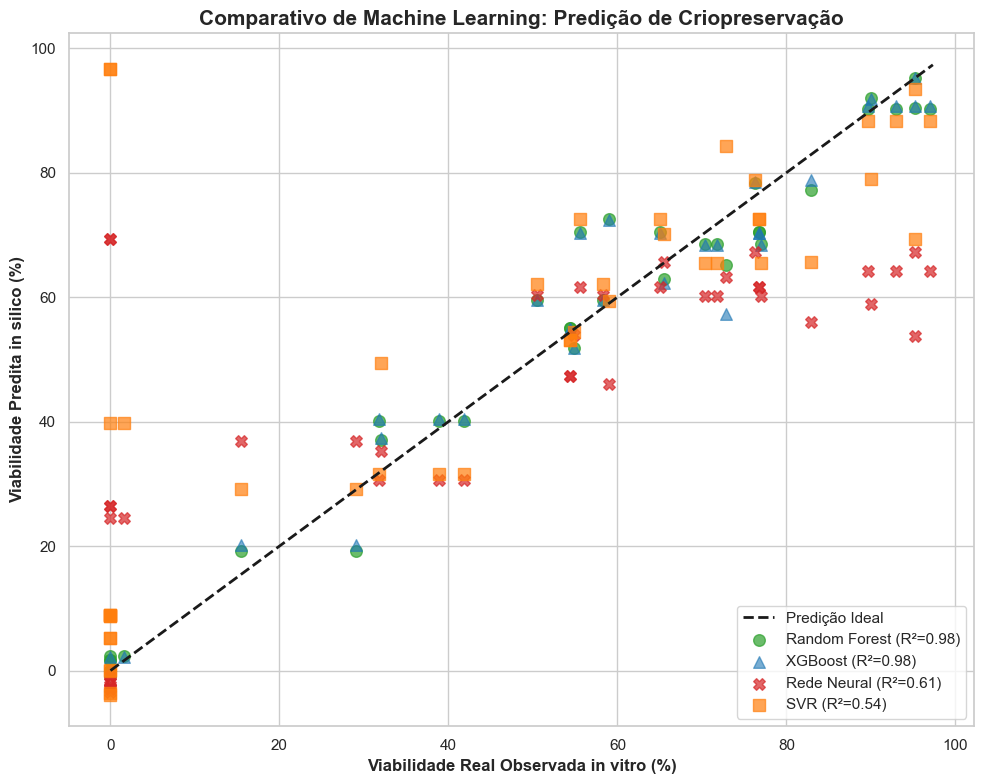

In [7]:
# Carregando o Random Forest salvo anteriormente
rf_model = joblib.load('random_forest_model.pkl')
y_pred_rf = rf_model.predict(X_test)

# Configurando o Gráfico Comparativo Geral
plt.figure(figsize=(10, 8))

# Linha Ideal
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Predição Ideal')

# Plotando as famílias de Árvores
plt.scatter(y_test, y_pred_rf, alpha=0.7, color='#2ca02c', label=f'Random Forest (R²={r2_score(y_test, y_pred_rf):.2f})', s=70)
plt.scatter(y_test, y_pred_xgb, alpha=0.6, color='#1f77b4', label=f'XGBoost (R²={r2_xgb:.2f})', s=70, marker='^')

# Plotando as famílias de Distância/Pesos
plt.scatter(y_test, y_pred_mlp, alpha=0.7, color='#d62728', label=f'Rede Neural (R²={r2_mlp:.2f})', s=70, marker='X')
plt.scatter(y_test, y_pred_svr, alpha=0.7, color='#ff7f0e', label=f'SVR (R²={r2_svr:.2f})', s=70, marker='s')

plt.xlabel('Viabilidade Real Observada in vitro (%)', fontweight='bold')
plt.ylabel('Viabilidade Predita in silico (%)', fontweight='bold')
plt.title('Comparativo de Machine Learning: Predição de Criopreservação', fontsize=15, fontweight='bold')
plt.legend()
plt.tight_layout()

# Salva
plt.savefig('comparativo_4_algoritmos.png', dpi=300)
plt.show()